## Plain PPP Value strategy

In [1]:
import pandas as pd
import numpy as np

In [2]:
#See data.py to find all the imports packages
from data import spt_dol_import

spt_dol = spt_dol_import()
#spt_dol.info()
#spt_dol.head()

#Importing PPP
from data import PPP_import
import pandas as pd

df_PPP = PPP_import()
df_PPP.head()

CURRENCY,AUD,BRL,CAD,CHF,CLP,CZK,EUR,GBP,HUF,IDR,...,INR,JPY,MXN,NOK,NZD,PLN,RUB,SEK,SGD,ZAR
TIME_PERIOD,,,,,,,,,,,,,,,,,,,,,
1960-01-01,0.700946,NaN,0.953324,2.189697,NaN,NaN,NaN,0.228426,NaN,NaN,...,NaN,170.580543,0.005534,6.181021,0.481728,NaN,NaN,4.472795,NaN,NaN
1961-01-01,0.701324,NaN,0.948670,2.256720,NaN,NaN,NaN,0.233865,NaN,NaN,...,NaN,182.091664,0.005717,6.283565,0.460293,NaN,NaN,4.559932,NaN,NaN
1962-01-01,0.687990,NaN,0.941626,2.334714,NaN,NaN,NaN,0.237129,NaN,NaN,...,NaN,185.490474,0.005762,6.435664,0.476968,NaN,NaN,4.636998,NaN,NaN
1963-01-01,0.698321,NaN,0.948107,2.412528,NaN,NaN,NaN,0.238316,NaN,NaN,...,NaN,192.886602,0.005883,6.558047,0.480126,NaN,NaN,4.696337,NaN,NaN
1964-01-01,0.708346,NaN,0.957314,2.495978,NaN,NaN,NaN,0.243610,NaN,NaN,...,NaN,199.585633,0.006167,6.746634,0.490676,NaN,NaN,4.816451,NaN,NaN


Now that we have the exchange rates in dollars (direct quote), we need the PPP ones such that we can compute $Qt = St(usd/f) * Pf/Pusd$

- If $Qt > 1$ then $St*Pf > Pusd$ => domestic prices are lower in real term => domestic competitiveness is enhanced => we can expect the exchange rate $St$ to decrease in order to get back to equilibrium : therefore we __short__ the foreign currency.
- If $Qt < 1$ => we go __long__ the foreign currency

$Pf/Pusd$ is given by the PPP database below (per dollar data)

In [3]:
#Croatia(Kuna) and Bulgaria(Levi) swithced to € recently so we drop them from the analysis
#df_corabulg = pd.read_csv("/Users/hirecheariles/Documents/Cours/Master Finance/International Finance/Project/CroaBulg.csv", sep =";")
#df_corabulg = df_corabulg[["TIME_PERIOD", "CURRENCY", "OBS_VALUE"]]
#df_corabulg

We match the order of the columns in the two dataframes

In [4]:
mapping = {'AUSTDOL(ER)': "AUD", 'BRACRUZ(ER)':'BRL', 'CNDOLLR(ER)':'CAD', 'CHILPES(ER)':'CLP',
       'USEURSP(ER)':"EUR", 'HUNFORT(ER)':"HUF", 'INDRUPE(ER)':"INR", 'INDORUP(ER)':"IDR",
       'ISRSHEK(ER)':"ILS", 'JAPAYEN(ER)':"JPY", 'MEXPESO(ER)':"MXN", 'NZDOLLR(ER)':"NZD",
       'NORKRON(ER)':"NOK", 'POLZLOT(ER)':"PLN", 'CISRUBM(ER)':"RUB", 'SINGDOL(ER)':"SGD",
       'COMRAND(ER)':"ZAR", 'SWEKRON(ER)':"SEK", 'SWISSFR(ER)':"CHF", 'CZECHCM(ER)':"CZK", 'GBP(ER)':"GBP"}
spt_dol = spt_dol.rename(columns=mapping)

We build the strategy with both monthly and quarterly rebalancement

In [5]:
#We rebalance on the median date to avoid any noise from month beginning
rebal_mth = spt_dol.index.to_series().groupby(spt_dol.index.to_period("M")).min() #Monthly rebalancement
rebal_qtr = spt_dol.index.to_series().groupby(spt_dol.index.to_period('Q')).min() #Quarterly rebalancement
rebal_qmed = spt_dol.index.to_series().groupby(spt_dol.index.to_period("Q")).median().dt.normalize() #Quarterly median date

Note that sometimes, the median date won't be a tradable one, but the trade would occur at the opening of the next trading session in any case

In [6]:
#We reindex the data to get a dataframe with observations at the right intervals
spt_mth = spt_dol.reindex(rebal_mth, method="ffill")
spt_qtr = spt_dol.reindex(rebal_qtr, method ="ffill")
spt_qmed = spt_dol.reindex(rebal_qmed, method="ffill")

df_PPPm = df_PPP.reindex(rebal_mth, method='ffill')
df_PPPq = df_PPP.reindex(rebal_qtr, method="ffill")
df_PPPqmed = df_PPP.reindex(rebal_qmed, method="ffill")

#Computing the Real Exchange Rate Qt for the different periods
df_RERm = spt_mth * df_PPPm 
df_RERq = spt_qtr * df_PPPq
df_RERqmed = spt_qmed * df_PPPqmed

df_RERq.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 108 entries, 1998-01-01 to 2024-10-01
Data columns (total 21 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AUD     108 non-null    float64
 1   BRL     108 non-null    float64
 2   CAD     108 non-null    float64
 3   CHF     108 non-null    float64
 4   CLP     108 non-null    float64
 5   CZK     108 non-null    float64
 6   EUR     108 non-null    float64
 7   GBP     108 non-null    float64
 8   HUF     108 non-null    float64
 9   IDR     108 non-null    float64
 10  ILS     108 non-null    float64
 11  INR     108 non-null    float64
 12  JPY     108 non-null    float64
 13  MXN     108 non-null    float64
 14  NOK     108 non-null    float64
 15  NZD     108 non-null    float64
 16  PLN     108 non-null    float64
 17  RUB     108 non-null    float64
 18  SEK     108 non-null    float64
 19  SGD     108 non-null    float64
 20  ZAR     108 non-null    float64
dtypes: float64(21)
memor

We compute the results of our analysis in sample first until 2015 and then OOS from 2015-2025.

In [7]:
spt_IS = spt_dol[:"2015"]
spt_OS = spt_dol["2015":]

df_RERmIS = df_RERm[:"2015"]
df_RERmOS = df_RERm["2015":]

df_RERqIS = df_RERq[:"2015"]
df_RERqOS = df_RERq["2015":]

df_RERqmedIS = df_RERqmed[:"2015"]
df_RERqmedOS = df_RERqmed["2015":]

rebal_mIS = rebal_mth[:"2015"]
rebal_qIS = rebal_qtr[:"2015"]
rebal_qmedIS = rebal_qmed[:"2015"]

rebal_mOS = rebal_mth["2015":]
rebal_qOS = rebal_qtr["2015":]
rebal_qmedOS = rebal_qmed["2015":]

In [8]:
from data import weightsPPPstrat
import numpy as np

weights_mIS = weightsPPPstrat(df_RERmIS, n_long=7)
weights_qIS = weightsPPPstrat(df_RERqIS, n_long=7)
weights_qmedIS = weightsPPPstrat(RERdf = df_RERqmedIS, n_long=7, rebal_dates=rebal_qmedIS)

monthly_retIS = np.log(spt_IS) - np.log(spt_IS.shift())
quarter_retIS = np.log(spt_IS.reindex(rebal_qIS)) - np.log(spt_IS.reindex(rebal_qIS).shift()) #Quarterly log returns
qmed_retIS = np.log(spt_IS.reindex(rebal_qmedIS, method="ffill")) - np.log(spt_IS.reindex(rebal_qmedIS, method="ffill").shift(1))

returns_mIS = (weights_mIS * monthly_retIS).sum(axis=1)
returns_qIS = (weights_qIS * quarter_retIS).sum(axis=1)
returns_qmedIS = (weights_qmedIS * qmed_retIS).sum(axis=1)

print(f"SharpeMIS = {12*returns_mIS.mean()/(returns_mIS.std()*np.sqrt(12))}")
print(f"SharpeQIS = {4*returns_qIS.mean()/(returns_qIS.std()*np.sqrt(4))}")
print(f"SharpeQmedIS = {4*returns_qmedIS.mean()/(returns_qmedIS.std()*np.sqrt(4))}")

returns_mIS.describe()

SharpeMIS = -0.03024849486953428
SharpeQIS = -0.35871577094707074
SharpeQmedIS = -0.38832964766939804


count    4696.000000
mean       -0.000008
std         0.000897
min        -0.023376
25%         0.000000
50%         0.000000
75%         0.000000
max         0.014277
dtype: float64

We find negative results... (before transaction cost!) and the less worst of all the strategies is the monthly one, which might not let the time of the negative effect of the bad trading decisions that we are taking to occur.

In [9]:
#On both IS and OS
weights_m = weightsPPPstrat(df_RERm, n_long=7)
weights_q = weightsPPPstrat(df_RERq, n_long=7)

monthly_ret = np.log(spt_dol) - np.log(spt_dol.shift())
quarter_ret = np.log(spt_dol.reindex(rebal_qtr)) - np.log(spt_dol.reindex(rebal_qtr).shift()) #Quarterly log returns

returns_m = (weights_m * monthly_ret).sum(axis=1)
returns_q = (weights_q * quarter_ret).sum(axis=1)

print(f"SharpeM = {12*returns_m.mean()/(returns_m.std()*np.sqrt(12))}")
print(f"SharpeQ = {4*returns_q.mean()/(returns_q.std()*np.sqrt(4))}")

returns_m.describe()

SharpeM = -0.0008460826255276415
SharpeQ = -0.2694874436308102


count    6.995000e+03
mean    -2.156199e-07
std      8.828089e-04
min     -2.337637e-02
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.427715e-02
dtype: float64

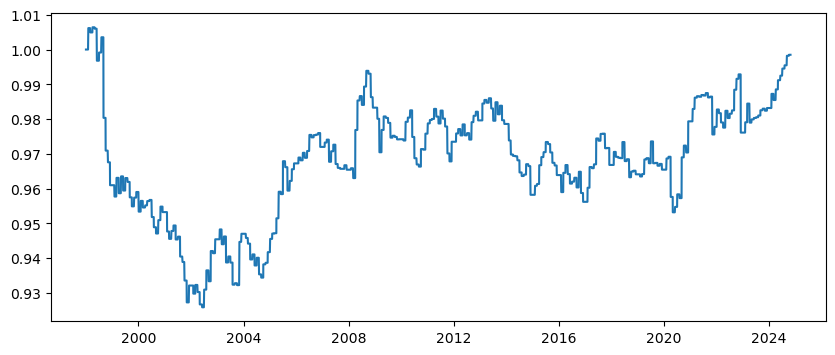

In [10]:
import matplotlib.pyplot as plt

plt.subplots(figsize=(10,4))
plt.plot(returns_m.index, np.exp(returns_m.cumsum()));

### We now try this PPP Value strategy only on G10 countries, as suggested by DB in 29 March, 2007

EUR (DEM pre-99), JPY, CHF, GBP, NOK, SEK, AUD, NZD, CAD

In [11]:
df_RERG10qIS = df_RERqIS[["AUD", "CAD", "CHF", "EUR", "GBP", "JPY", "NOK", "NZD", "SEK"]]
df_RERG10mIS = df_RERmIS[["AUD", "CAD", "CHF", "EUR", "GBP", "JPY", "NOK", "NZD", "SEK"]]

weightsG10qIS = weightsPPPstrat(df_RERG10qIS) #Calling the function to copmute weights
weightsG10mIS = weightsPPPstrat(df_RERG10mIS)

## Quarterly Strategy
spt_G10qIS = spt_dol.reindex(rebal_qIS, method="ffill") #Only keeping quarters
logret_G10qIS = np.log(spt_G10qIS) - np.log(spt_G10qIS.shift(1))

returns_G10qIS =(logret_G10qIS * weightsG10qIS).sum(axis=1) #Total on each qtr

#Monthly strategy
spt_G10mIS = spt_dol.reindex(rebal_mIS, method="ffill")
logret_G10mIS = np.log(spt_G10mIS) - np.log(spt_G10mIS.shift(1))

returns_G10mIS =(logret_G10mIS * weightsG10mIS).sum(axis=1) 

print(f"Sharpe q= {(4*returns_G10qIS.mean())/(np.sqrt(4)*returns_G10qIS.std())}")
print(f"Sharpe m= {(12*returns_G10mIS.mean())/(np.sqrt(12)*returns_G10mIS.std())}")

print(returns_G10qIS.describe(), returns_G10mIS.describe())
import scipy.stats as sps
print(f'Skew qtr={sps.skew(returns_G10qIS).round(6)}\nKurtosis qtr={sps.kurtosis(returns_G10qIS, fisher=True).round(6)}')
print(f'Skew mth={sps.skew(returns_G10mIS).round(6)}\nKurtosis mth={sps.kurtosis(returns_G10mIS, fisher=True).round(6)}')

Sharpe q= 0.3813361267313416
Sharpe m= 0.3166860259421145
count    72.000000
mean      0.007022
std       0.036829
min      -0.085912
25%      -0.017164
50%       0.003947
75%       0.032795
max       0.086694
dtype: float64 count    216.000000
mean       0.001983
std        0.021689
min       -0.059116
25%       -0.009825
50%        0.000630
75%        0.016143
max        0.063723
dtype: float64
Skew qtr=-0.021421
Kurtosis qtr=-0.275569
Skew mth=-0.098576
Kurtosis mth=0.515365


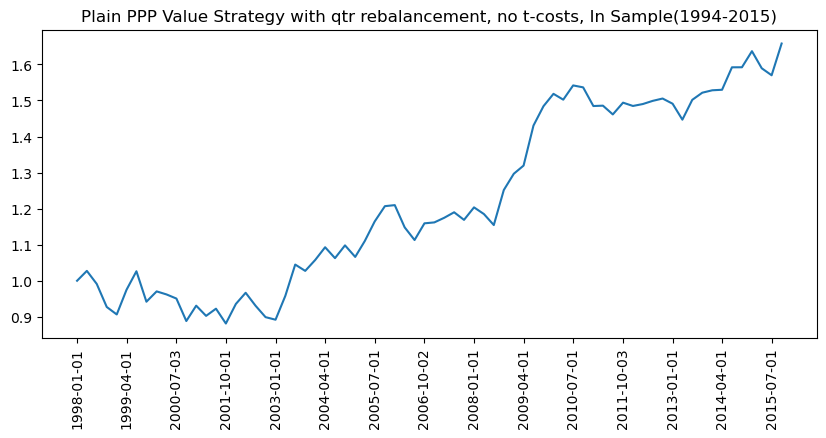

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(returns_G10qIS.index, np.exp(returns_G10qIS.cumsum()))
ax.set_xticks(returns_G10qIS.index[::5])
ax.tick_params(axis="x", rotation=90)
ax.set_title("Plain PPP Value Strategy with qtr rebalancement, no t-costs, In Sample(1994-2015)")

plt.show()

## We compute our results out of sample

In [13]:
df_RERG10qOS = df_RERqOS[["AUD", "CAD", "CHF", "EUR", "GBP", "JPY", "NOK", "NZD", "SEK"]]

weightsG10qOS = weightsPPPstrat(df_RERG10qOS, print_short=True) #Calling the function to copmute weights

## Quarterly Strategy
spt_G10qOS = spt_dol.reindex(rebal_qtr, method="ffill") #Only keeping quarters
logret_G10qOS = np.log(spt_G10qOS) - np.log(spt_G10qOS.shift(1))

returns_G10qOS =(logret_G10qOS * weightsG10qOS).sum(axis=1) #Total on each qtr

print(f"Sharpe q= {(4*returns_G10qOS.mean())/(np.sqrt(4)*returns_G10qOS.std())}")

print(returns_G10qOS.describe())
import scipy.stats as sps
print(f'Skew qtr={sps.skew(returns_G10qOS).round(6)}\nKurtosis qtr={sps.kurtosis(returns_G10qOS, fisher=True).round(6)}')

                 AUD  CAD       CHF  JPY       NOK  NZD      SEK
Code                                                            
2015-01-01  1.206000  NaN  1.243350  NaN  1.324769  NaN      NaN
2015-04-01  1.122794  NaN  1.277136  NaN  1.235026  NaN      NaN
2015-07-01  1.129814  NaN  1.308265  NaN  1.258083  NaN      NaN
2015-10-01       NaN  NaN  1.267147  NaN  1.178929  NaN  1.06118
2016-01-01  1.055082  NaN  1.200742  NaN  1.134501  NaN      NaN 
Sharpe q= 0.23109110645946848
count    108.000000
mean       0.001595
std        0.013805
min       -0.054648
25%        0.000000
50%        0.000000
75%        0.000000
max        0.054554
dtype: float64
Skew qtr=0.428788
Kurtosis qtr=5.817306


We get slightly worst results out of sample, as we face the 2015-2020 period, but extending until most recent 2026 data should help from that persprective.

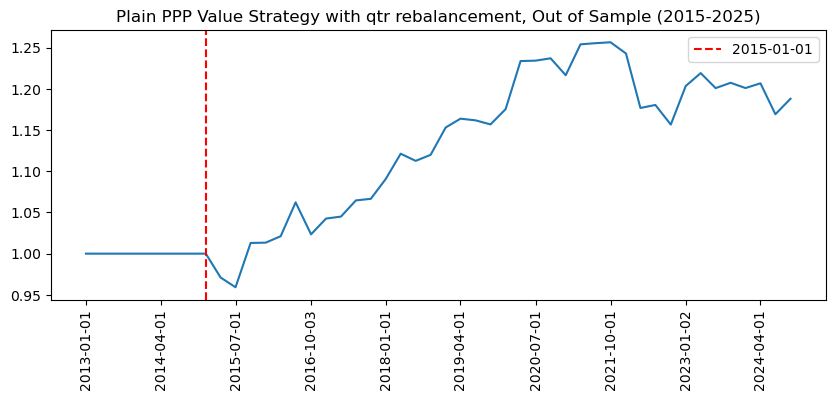

In [15]:
fig, ax = plt.subplots(figsize=(10,3.5))
ax.plot(returns_G10qOS.index[60:], np.exp(returns_G10qOS.cumsum()[60:]))
ax.set_xticks(returns_G10qOS.index[60::5])
ax.tick_params(axis="x", rotation=90)
ax.set_title("Plain PPP Value Strategy with qtr rebalancement, Out of Sample (2015-2025)")
ax.axvline(pd.to_datetime("01-01-2015"), color='r', linestyle="--", label='2015-01-01')
ax.legend()

plt.show()

<u>Conclusion :<u/> 
- We obtain positive returns out of sample, with a difficult start and a cap around 2020 levels.
- This is a nice return profile which, if nicely captured by our macro factor, will allow to provide performance when it is supposed to be hard (2016-2020) and let other asset classes thrive when the market is opportune for Value strategies (2020-onward, with multiple stressed periods).

##### We can get more precisions of the PPP spot rate within a year using CPI differential to modelise intra-year evolution.

##### Another limit is that we dropped the cost of carry allowing to compute precise excess returns for the Sharpe ratios. We make the choice to ignore the yield differential between two currencies, which might be in our favour as it might not, since risk free rate hasn't been shown as a main reason for PPP deviation (the 4 main ones being the HBS effect, the export quality, net foreign assets and the output gap, according to Menkhoff et al., 2015). 
##### As an example, when digging furthoer into our results (using 'print_short=True' as an argument of the weightsPPPstrat() function), we find that AUD and CHF happens to be shorted, the former economy being known for particularly high interest, while the second for consistent low rates.

##### However, for the purpose of our exercise, we've found a theory-consistent strategy, providing positive results, even during the 2015-2020 period. This allows us to diversify with other asset classes, even after adding transaction costs (see "Stratégie globale" folder).